In [12]:
import pandas as pd
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
import plotly.express as px
import dash
from dash import html, dcc
from dash.dependencies import Input, Output
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score
from sklearn import tree


df  = pd.read_csv("data/employee.csv")

display(Markdown("### Estructura y Consistencia de los Datos"))
info_df = pd.DataFrame({
    'Tipo de Dato': df.dtypes,
    'Registros No Nulos': df.notnull().sum(),
    'Valores Faltantes (%)': (df.isnull().sum() / len(df) * 100).round(2)
})
display(info_df)

display(Markdown("### Vista Previa del Histórico (Primeros 10 Registros)"))
display(df.head(10))

### Estructura y Consistencia de los Datos

,Tipo de Dato,Registros No Nulos,Valores Faltantes (%)
Education,object,4653,0.0
JoiningYear,int64,4653,0.0
City,object,4653,0.0
PaymentTier,int64,4653,0.0
Age,int64,4653,0.0
Gender,object,4653,0.0
EverBenched,object,4653,0.0
ExperienceInCurrentDomain,int64,4653,0.0
LeaveOrNot,int64,4653,0.0


### Vista Previa del Histórico (Primeros 10 Registros)

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0
1,Bachelors,2013,Pune,1,28,Female,No,3,1
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0
3,Masters,2016,Bangalore,3,27,Male,No,5,1
4,Masters,2017,Pune,3,24,Male,Yes,2,1
5,Bachelors,2016,Bangalore,3,22,Male,No,0,0
6,Bachelors,2015,New Delhi,3,38,Male,No,0,0
7,Bachelors,2016,Bangalore,3,34,Female,No,2,1
8,Bachelors,2016,Pune,3,23,Male,No,1,0
9,Masters,2017,New Delhi,2,37,Male,No,2,0


#### Dataset desbalanceado: evaluación de simetría en los datos
Un dataset desbalanceado ocurre cuando una categoría es mucho más frecuente que las otras (por ejemplo, si el 90% de los datos binarios son 0, solo el 10% son 1), esto puede llegar a traer problemas la hora de entrenar un modelo o evaluar el desempeño de este debido a que la variable minoritaria tiende a ser ignorada y genera un sesgo en cuanto a la importancia.

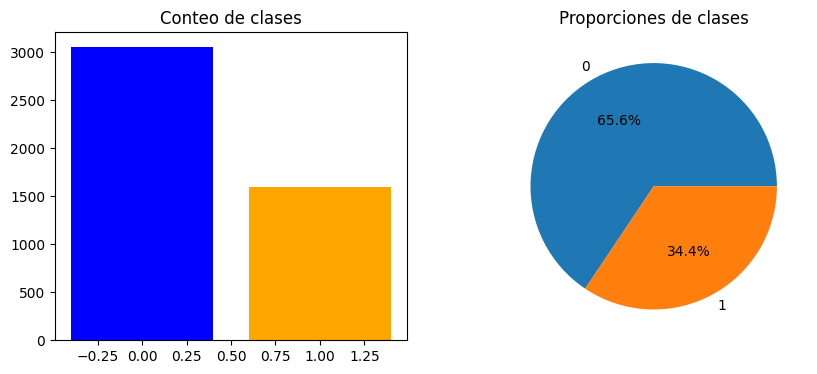

In [13]:
var_count = df["LeaveOrNot"].value_counts().reset_index()

fig, ax = plt.subplots(1,2, figsize=(10,4))

ax[0].bar(var_count["LeaveOrNot"], var_count["count"], color=["b","orange"])
ax[0].set_title("Conteo de clases")
ax[1].pie(var_count["count"], labels=var_count["LeaveOrNot"], autopct='%1.1f%%')
ax[1].set_title("Proporciones de clases")

plt.subplots_adjust(wspace=0.2, hspace=0.3)
plt.show()

In [14]:
target = "LeaveOrNot"
city_var = ["City"]
ordinal_vars = ["Education", "Gender", "EverBenched"]

df_encoded = pd.get_dummies(df, columns=city_var, prefix="City")

encoder = OrdinalEncoder()
df_encoded[ordinal_vars] = encoder.fit_transform(df[ordinal_vars])

map = {0:"permanece", 1:"sale"}
df["LeaveOrNot_txt"] = df["LeaveOrNot"].apply(lambda x : map.get(x))

cols_no_target = [c for c in df_encoded.columns if c != target]
X_train_columns = cols_no_target
df_final = df_encoded[cols_no_target + [target]]

display(Markdown("### DataSet Pre-procesado"))
display(df.head(10))

### DataSet Pre-procesado

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot,LeaveOrNot_txt
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0,permanece
1,Bachelors,2013,Pune,1,28,Female,No,3,1,sale
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0,permanece
3,Masters,2016,Bangalore,3,27,Male,No,5,1,sale
4,Masters,2017,Pune,3,24,Male,Yes,2,1,sale
5,Bachelors,2016,Bangalore,3,22,Male,No,0,0,permanece
6,Bachelors,2015,New Delhi,3,38,Male,No,0,0,permanece
7,Bachelors,2016,Bangalore,3,34,Female,No,2,1,sale
8,Bachelors,2016,Pune,3,23,Male,No,1,0,permanece
9,Masters,2017,New Delhi,2,37,Male,No,2,0,permanece


#### CART: nodos que determinan la salida de un empleado
Algoritmos basados en calcular umbrales que determinen el resultado de una variable, de manera iterativa se generan particiones sobre la región de información hasta llegar a una formación de grupo lo más homogénea posible, haciendo analogía a la estructura de un árbol, a partir de la raíz principal se extienden nodos adicionales que representan una condición y hojas que indican la pureza en su región de clases, de esta manera su trayectoria consiste en integorrantes de si o no junto con respuestas asociadas y la fiabilidad de estas. En el caso de la complejidad del comportamiento humano, el particionamiento recursivo de las variables discretas y continuas actúan como disparadores estadísticos de la salida cuando se cruzan con el contexto sociodemográfico del empleado, esta capacidad del modelo para gestionar la complejidad no lineal es fundamental, ya que permite al negocio entender a la rotación como el resultado de interacciones multivariables donde la analítica técnica y las características de RRHH convergen para revelar patrones ocultos en el ciclo de vida laboral.

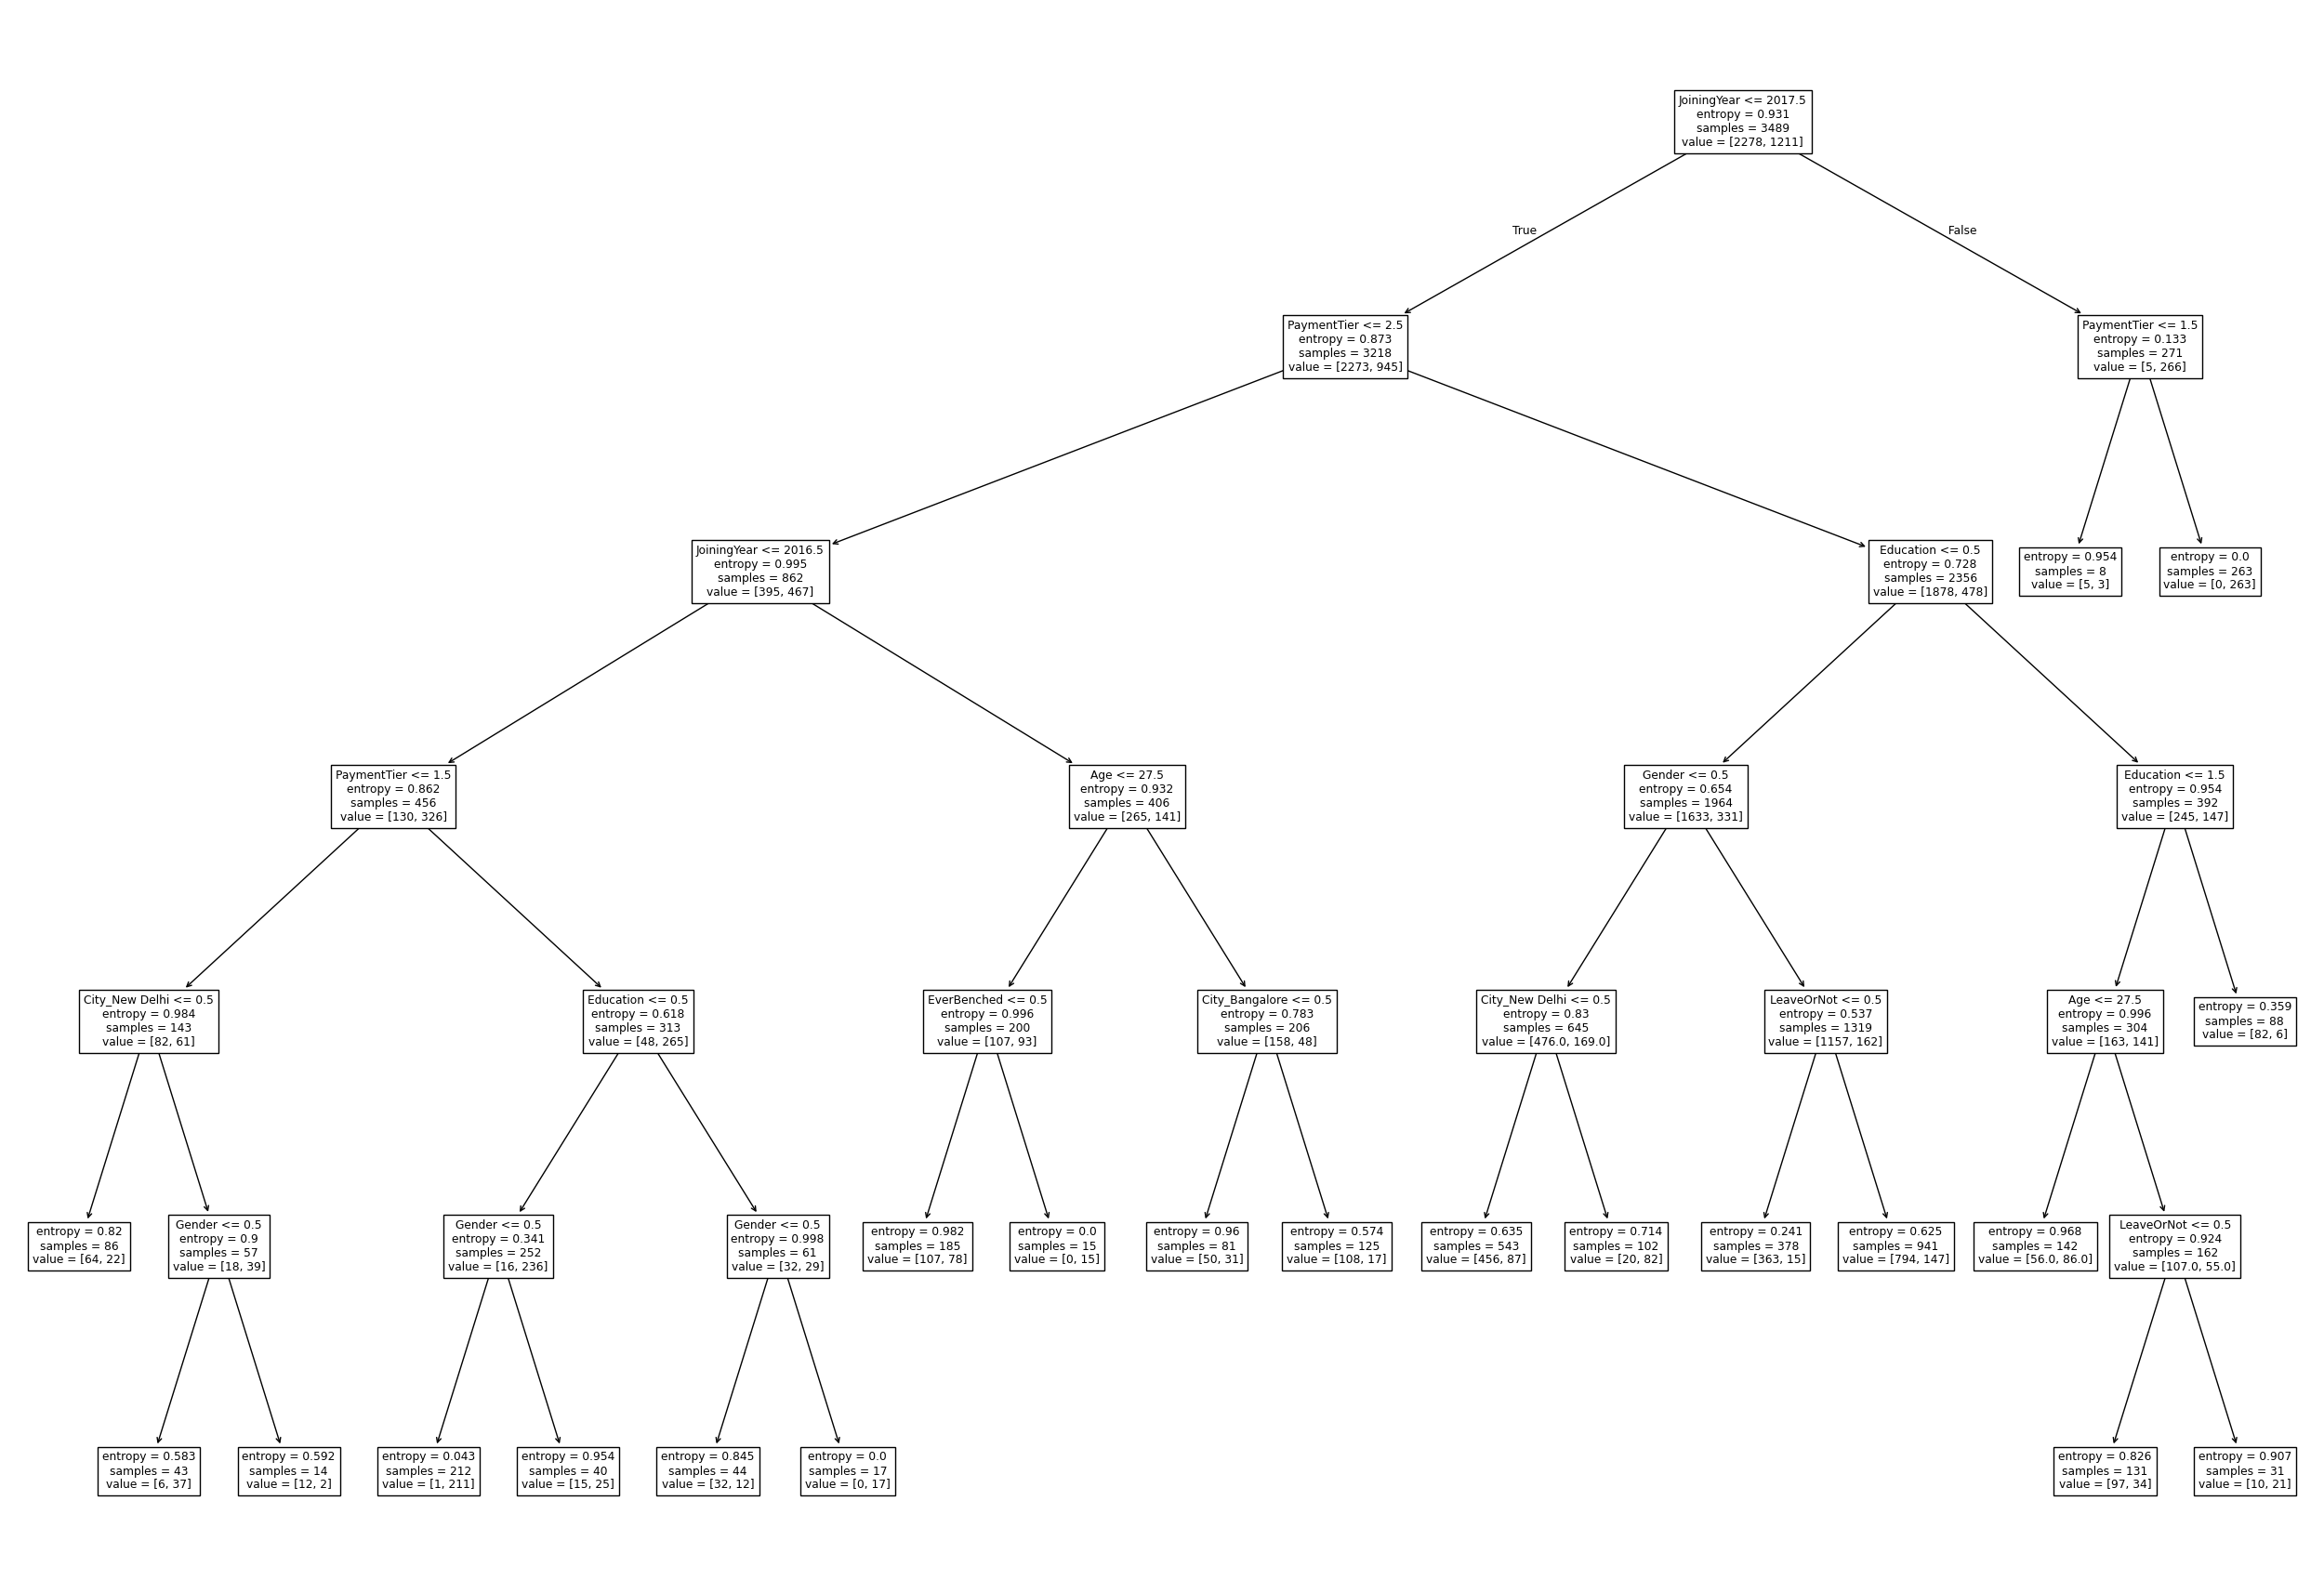

In [9]:
x_train, x_test, y_train, y_test = train_test_split(df_final[cols_no_target],
                                                   df_final[target],
                                                   test_size=0.25,
                                                   random_state=42)

tree_decision_clf = tree.DecisionTreeClassifier(criterion="entropy",
                                           max_depth=6,
                                           min_samples_split=6,
                                           min_samples_leaf=5,
                                           ccp_alpha=0.003)

model = tree_decision_clf.fit(x_train, y_train)

class_predicts = model.predict(x_test)

class_real = y_test.values

matrix_confusion = confusion_matrix(class_real,class_predicts)
TP = matrix_confusion[0,0]
FP = matrix_confusion[0,1]
FN = matrix_confusion[1,0]
TN = matrix_confusion[1,1]

accuracy = accuracy_score(class_real, class_predicts)
color_accuracy = "green"
if accuracy < 0.6:
    color_accuracy = "red"
accuracy_str = str(accuracy)

recall = recall_score(class_real, class_predicts)
color_recall = "green"
if recall < 0.6:
    color_recall = "red"
recall_str = str(recall)

precision = precision_score(class_real, class_predicts)
color_precision = "green"
if precision < 0.6:
    color_precision = "red"
precision_str = str(precision)

F1_score = f1_score(class_real, class_predicts)
color_f1 = "green"
if F1_score < 0.6:
    color_f1 = "red"
F1_score_str = str(F1_score)

plt.figure(figsize=(32,22))
tree.plot_tree(model, feature_names=df_encoded.columns[:-1])
plt.show()

#### Dashboard con enfoque técnico que describe indicadores de riesgo y registra el rendimiento del modelo

In [ ]:
predict_leave_percentage = class_predicts.flatten().mean() * 100
predict_not_leave_percentage = 100 - predict_leave_percentage

real_leave_percentage = class_real.flatten().mean() * 100
real_not_leave_percentage = 100 - real_leave_percentage

app = dash.Dash(__name__)

app.layout = html.Div(id="body",className="e1_body",children=[
html.H1("Análisis predictivo de rotación de personal",id="title",className="e1_title",style={"margin-bottom":"50px"}),
html.Div(className="e1_dashboards",children=[
    html.Div(id="graph_div_1",className="e1_graph_div",children=[
        html.Div(id="dropdown_div_1",className="e1_dropdown_div",children=[
            dcc.Dropdown(id="dropdown_1",className="e1_dropdown",
                        options = [
                            {"label":"Educación","value":"Education"},
                            {"label":"Año de incorporación","value":"JoiningYear"},
                            {"label":"Ciudad","value":"City"},
                            {"label":"Género","value":"Gender"},
                            {"label":"Siempre en banca","value":"EverBenched"}
                        ],
                        value="Education",
                        multi=False,
                        clearable=False)
        ]),
        dcc.Graph(id="barchart_1",className="e1_graph",figure={})
    ]),
    html.Div(id="graph_div_2",className="e1_graph_div",children=[
        html.Div(id="dropdown_div_2",className="e1_dropdown_div",children=[
            dcc.Dropdown(id="dropdown_2",className="e1_dropdown",
                        options = [
                            {"label":"Edad","value":"Age"},
                            {"label":"Nivel de pago","value":"PaymentTier"},
                            {"label":"Experiencia en el dominio","value":"ExperienceInCurrentDomain"}
                        ],
                        value="Age",
                        multi=False,
                        clearable=False)
        ]),
        dcc.Graph(id="barchart_2",className="e1_graph",figure={})
    ]),
]),

    html.Div(className="e1_div", children=[
        html.Div(id="performance", className="e1_performance",children=[
            html.P([html.B("Clases reales", style={"color":"blue"}),"   vs.   ",html.B("Predicciones",style={"color":"red"})], style={"text-align":"center","font-family":"sans-serif"}),
            html.P(f"{round(predict_not_leave_percentage)}% permanece | {round(predict_leave_percentage)}% sale", className="e1_predicts"),
            html.P("-----------------------------------------------------------------",style={"margin":"0"}),
            html.P(f"{round(real_not_leave_percentage)}% permanece | {round(real_leave_percentage)}% sale", className="e1_real_class")
        ])
        html.Div(id="metrics", className="e1_metrics", children=[
                html.P("Matriz de confusión", style={"font-size":"0.92em","text-align":"center","font-family":"sans-serif","font-weigth":"bold","margin-top":"15px"}),
                html.Div(id="matrix", className="e1_matrix", children=[
                html.Div([html.B(TP,style={"color":"green","font-family":"sans-serif"})],id="TP",className="e1_successes"),
                html.Div([html.B(FP,style={"color":"red","font-family":"sans-serif"})],id="FP",className="e1_mistakes"),
                html.Div([html.B(FN,style={"color":"red","font-family":"sans-serif"})],id="FN",className="e1_mistakes"),
                html.Div([html.B(TN,style={"color":"green","font-family":"sans-serif"})],id="TN",className="e1_successes")
                ]),
                html.Div(id="scores",children=[
                html.Ul(id="list",children=[
                html.Li([f"Accuracy: ",html.B(accuracy_str[:4],style={"color":f"{color_accuracy}"})],id="accuracy",className="e1_score"),
                html.Li([f"Recall: ",html.B(recall_str[:4],style={"color":f"{color_recall}"})],id="recall",className="e1_score"),
                html.Li([f"Precision: ",html.B(precision_str[:4],style={"color":f"{color_precision}"})],id="precision",className="e1_score"),
                html.Li([f"F1 Score: ",html.B(F1_score_str[:4],style={"color":f"{color_f1}"})],id="f1_score",className="e1_score")
                ])

            ])
        ])
    ])
])


@app.callback(
    [Output(component_id="barchart_1",component_property="figure"),
    Output(component_id="barcahrt_2",component_property="figure")],
    [Input(component_id="dropdown_1",component_property="value"),
    Input(component_id="dropdown_2",component_property="value")]
)

def update_dashboard(slct_var_cat, slct_var_num):

    df_stats = df.groupby(slct_var_cat).agg(exit_probability=("LeaveOrNot", "mean"), sample_size=("LeaveOrNot", "count")).reset_index()
    df_stats["probability_pct"] = (df_stats["exit_probability"] * 100).round(1)
    df_stats["display_label"] = (df_stats[slct_var_cat].astype(str) + " (n=" + df_stats["sample_size"].astype(str) + ")")

    exit_risk_bar = px.bar(
        df_stats,
        x="display_label",
        y="probability_pct",
        text="probability_pct",
        title="Riesgo de salida",
        labels={"probability_pct": "Probabilidad de Salida (%)", "display_label": slct_var_cat},
        color="probability_pct",
        color_continuous_scale="Reds"
    )

    exit_risk_bar.update_traces(texttemplate="%{text}%", textposition="outside")
    exit_risk_bar.update_layout(xaxis={"categoryorder": "total descending"}, yaxis_range=[0, 100], yaxis_title="Employee Churn", coloraxis_showscale=False, margin=dict(t=50, l=25, r=25, b=25))

    df_mean = df.groupby("LeaveOrNot_txt")[slct_var_num].mean().reset_index()

    mean_comparison_bar = px.bar(
        df_mean,
        x="LeaveOrNot_txt",
        y=slct_var_num,
        text=slct_var_num,
        title="Comparación de medias",
        color="LeaveOrNot_txt",
        color_discrete_sequence=px.colors.qualitative.Safe
    )

    mean_comparison_bar.update_traces(texttemplate="%{text:.2f}", textposition="outside")
    mean_comparison_bar.update_layout(xaxis_title="Employee Status", yaxis_title=" ",  yaxis_range=[0, 35], showlegend=False, margin=dict(t=50, l=25, r=25, b=25))

    return exit_risk_bar, mean_comparison_bar

if __name__ == "__main__":
    app.run(debug=False)